In [16]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configurar el tamaño estándar de los gráficos con matplotlib
plt.rcParams["figure.figsize"] = (10, 6)

# Cargar el dataset limpio 
df_eda = pd.read_csv("../data/processed/streaming_dataset_limpio.csv")

# Verificar las primeras filas del DataFrame
df_eda.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
1,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
2,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
3,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1
4,10005,20,Básico,670.2,Uruguay,Drama,2020-07-03,2


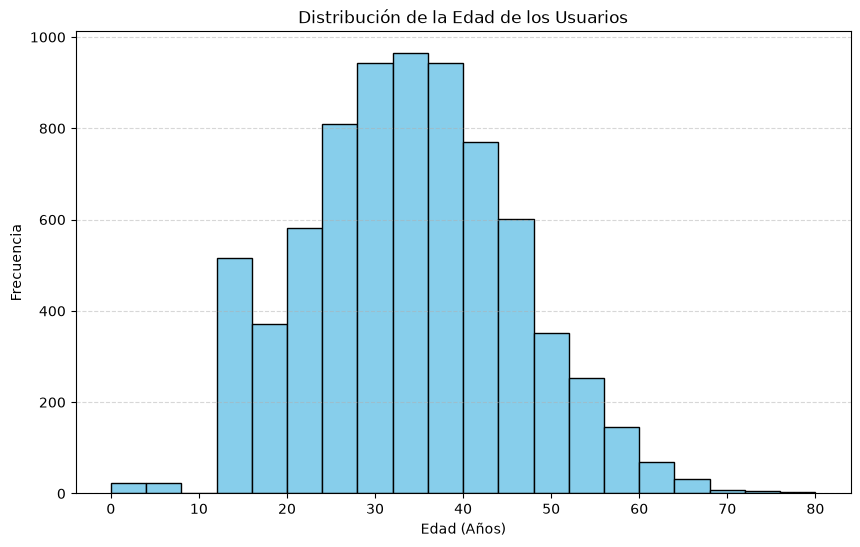

In [17]:
# 1. Análisis univariado: Histograma de Edad
plt.hist(df_eda["age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribución de la Edad de los Usuarios")
plt.xlabel("Edad (Años)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

El primer gráfico univariado sobre la edad revela una fuerte concentración de usuarios entre los 25 y 45 años, teniendo su pico a los 35 años. También, se observa una concentración secundaria desde los 12 a 16 años, lo que evidencia el interés de los adolescentes sobre el streaming, por último, la cantidad de usuarios empieza a decaer a partir de los 55 años.

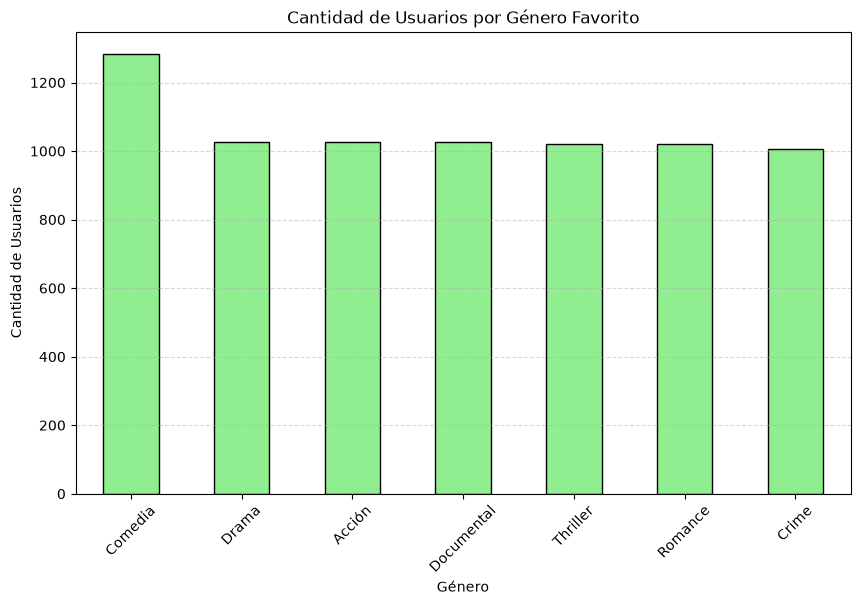

In [18]:
# 2. Análisis univariado: Gráfico de barras de Género Favorito
df_eda["favorite_genre"].value_counts().plot(
    kind="bar", color="lightgreen", edgecolor="black"
)
plt.title("Cantidad de Usuarios por Género Favorito")
plt.xlabel("Género")
plt.ylabel("Cantidad de Usuarios")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

El gráfico sobre el género favorito, muestra que los usuarios prefieren el género de comedia, y los demás géneros se distribuyen uniformemente, manteniéndose estables

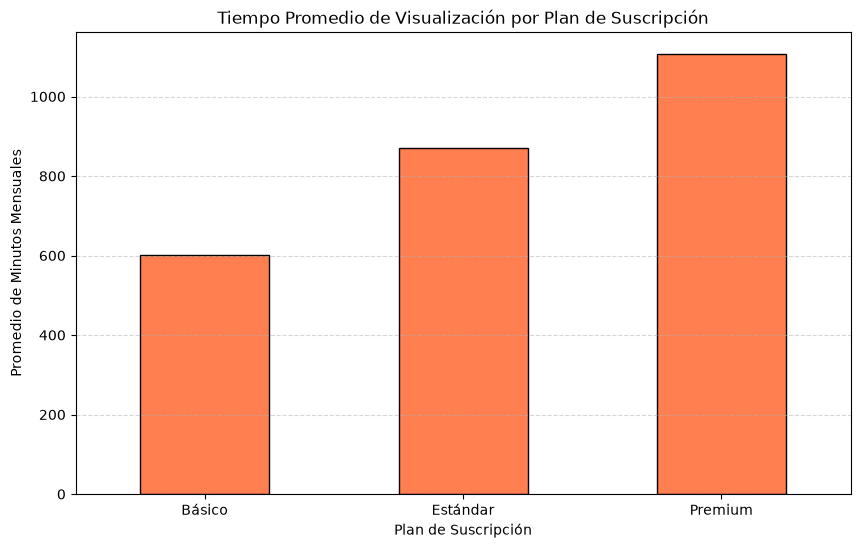

In [19]:
# 3. Análisis bivariado: Gráfico de barras de Tiempo Promedio por Plan
df_eda.groupby("subscription_plan")["monthly_watch_time_mins"].mean().plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("Tiempo Promedio de Visualización por Plan de Suscripción")
plt.xlabel("Plan de Suscripción")
plt.ylabel("Promedio de Minutos Mensuales")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

El gráfico del análisis bivariado sobre el plan de suscripción y el tiempo de visualización revela que a medida que el plan aumenta, los usuarios aumentan el consumo de visualización



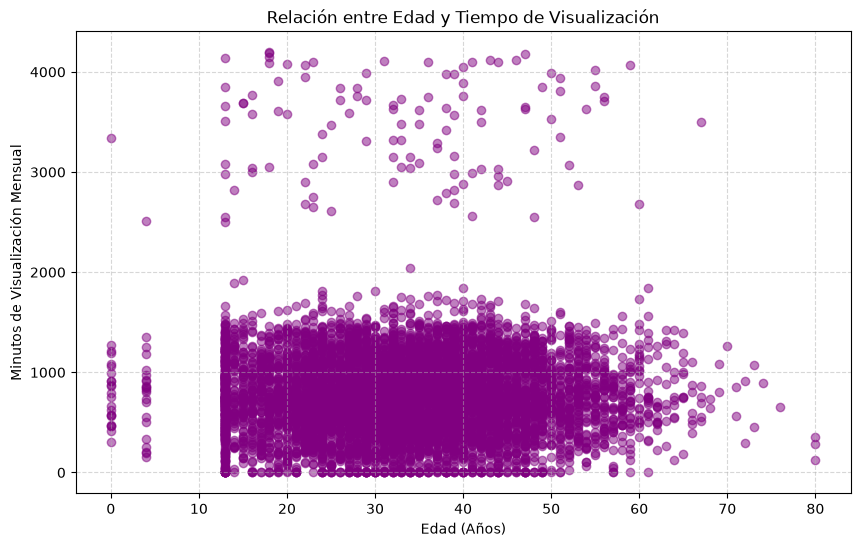

In [20]:
# 4. Análisis bivariado: Scatter plot de Edad vs. Tiempo de Visualización
plt.scatter(
    df_eda["age"], df_eda["monthly_watch_time_mins"], color="purple", alpha=0.5
)
plt.title("Relación entre Edad y Tiempo de Visualización")
plt.xlabel("Edad (Años)")
plt.ylabel("Minutos de Visualización Mensual")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Mediante éste gráfico de dispersión y las variables de edad y los minutos de visualización, se revela un patrón de comportamiento marcado, la mayoría de los usuarios consumen alrededor de 1600 minutos mensuales a lo largo de las edades, aunque también, se observa que hay un grupo de usuarios con consumos entre los 2000 y 4000 minutos mensuales, éste consumo se concentra desde los 12/13 años y empieza a disminuir desde los 60 años

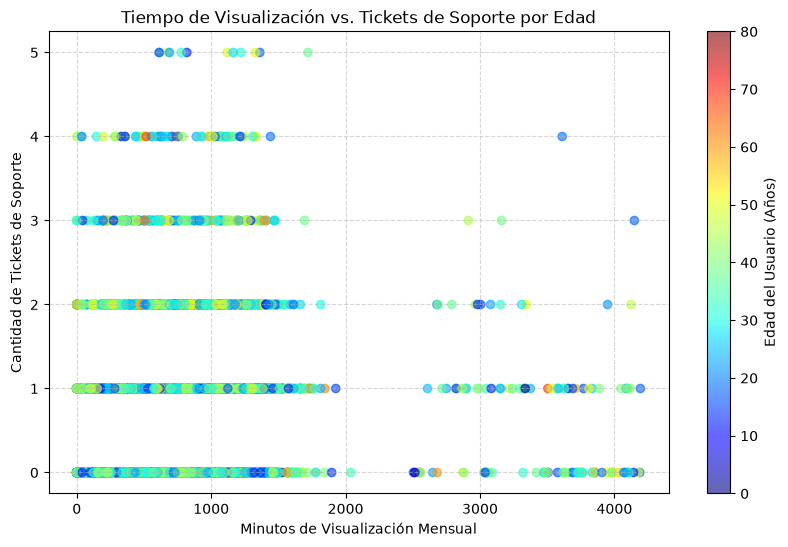

In [21]:
# 5. Análisis multivariado: Scatter plot de Tiempo vs. Tickets con Color por Edad
plt.scatter(
    df_eda["monthly_watch_time_mins"],
    df_eda["customer_support_tickets"],
    c=df_eda["age"],
    cmap="jet",
    alpha=0.6,
)
plt.title("Tiempo de Visualización vs. Tickets de Soporte por Edad")
plt.xlabel("Minutos de Visualización Mensual")
plt.ylabel("Cantidad de Tickets de Soporte")
plt.colorbar(label="Edad del Usuario (Años)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Mediante este gráfico multivariado se observa que los tickets de soporte se mantienen controlados con un máximo de 5 reclamos por mes. Además, se revela que los usuarios con más minutos de visualización (entre 2500 y 4200 minutos) concentran sus reclamos únicamente en las franjas más bajas de 0 a 2 tickets, y la mezcla homogénea de colores demuestra que la edad no influye en la cantidad de problemas técnicos.